In [3]:
import pandas as pd
import numpy as np
import re
import os

out_dir = r"C:\Users\user\Downloads\GSE148812_clean"
manifest_path = r"C:\Users\user\Downloads\HumanExome-12-v1-0-B.csv"

def strip_address_suffix(pid):
    return re.sub(r'_\d+$', '', pid)

# rebuild standardized matrix (relatedness-filtered data)
encoded_df = pd.read_csv(os.path.join(out_dir, "checkpoint7b_snp_encoded_012_relatedness_filtered.csv"))
probe_id_array = encoded_df["probe_id"].to_numpy()
sample_cols = encoded_df.columns[1:]
sample_ids = sample_cols.tolist()
X_snp_first = encoded_df[sample_cols].to_numpy(dtype=np.int8)
del encoded_df

manifest_df = pd.read_csv(manifest_path, skiprows=7, low_memory=False)
non_autosomal = {"X", "Y", "XY", "MT", "0"}
sex_linked_probes = set(manifest_df.loc[manifest_df["Chr"].isin(non_autosomal), "IlmnID"])
sex_linked_core_names = {strip_address_suffix(p) for p in sex_linked_probes}
our_probe_core_names = {strip_address_suffix(p): p for p in probe_id_array}
to_exclude = {our_probe_core_names[c] for c in sex_linked_core_names if c in our_probe_core_names}

keep_mask = ~np.isin(probe_id_array, list(to_exclude))
X_auto = X_snp_first[keep_mask].T.astype(np.float64)
del X_snp_first

p = X_auto.mean(axis=0) / 2
denom = np.sqrt(2 * p * (1 - p))
valid_snp_mask = denom > 1e-8
X_standardized = (X_auto[:, valid_snp_mask] - 2 * p[valid_snp_mask]) / denom[valid_snp_mask]
del X_auto

probe_ids_valid = probe_id_array[keep_mask][valid_snp_mask]
probe_id_to_idx = {pid: i for i, pid in enumerate(probe_ids_valid)}
print("X_standardized shape:", X_standardized.shape)

# outcome
meta_df = pd.read_csv(os.path.join(out_dir, "checkpoint2b_metadata_relatedness_filtered.csv"))
meta_df["sample_id"] = meta_df["sample_id"].astype(str)
status_map = meta_df.set_index("sample_id")["smoking_status"]
Y = np.array([1.0 if status_map.get(sid) == "Smoker" else 0.0 for sid in sample_ids])
print("Y distribution:", np.unique(Y, return_counts=True))

# load the final sensitivity shortlist
shortlist_100_final = pd.read_csv(os.path.join(out_dir, "shortlist_smoking_100pct_final.csv"))
print("Shortlist size:", len(shortlist_100_final))

X_standardized shape: (1460, 127416)
Y distribution: (array([0., 1.]), array([665, 795]))
Shortlist size: 18


In [4]:
import json

final_ids = shortlist_100_final["probe_id"].tolist()
print("Final SNP count:", len(final_ids))

final_col_indices = [probe_id_to_idx[pid] for pid in final_ids]
X_pc = X_standardized[:, final_col_indices]

col_names = final_ids + ["smoking_status"]
X_pc_full = np.hstack([X_pc, Y.reshape(-1, 1)])

print("PC input shape:", X_pc_full.shape)

np.save(os.path.join(out_dir, "pc_input_smoking_sensitivity.npy"), X_pc_full)
with open(os.path.join(out_dir, "pc_col_names_smoking_sensitivity.json"), "w") as f:
    json.dump(col_names, f)
print("Saved.")

Final SNP count: 18
PC input shape: (1460, 19)
Saved.


In [5]:
import numpy as np
import json
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import time
import os

out_dir = r"C:\Users\user\Downloads\GSE148812_clean"

X_pc_full = np.load(os.path.join(out_dir, "pc_input_smoking_sensitivity.npy"))
with open(os.path.join(out_dir, "pc_col_names_smoking_sensitivity.json")) as f:
    col_names = json.load(f)

n_nodes = len(col_names)
outcome_idx = col_names.index("smoking_status")
print("Input shape:", X_pc_full.shape)
print("n_nodes:", n_nodes)

bk = BackgroundKnowledge()
nodes = [GraphNode(name) for name in col_names]
for i in range(n_nodes - 1):
    bk.add_node_to_tier(nodes[i], 0)
bk.add_node_to_tier(nodes[outcome_idx], 1)

start = time.time()
cg = pc(
    data=X_pc_full,
    alpha=0.001,
    indep_test=fisherz,
    stable=True,
    uc_rule=0,
    uc_priority=2,
    background_knowledge=bk,
    verbose=False,
    show_progress=True,
    node_names=col_names
)
elapsed = time.time() - start
print(f"Completed in {elapsed:.1f}s")
print("Nodes:", len(cg.G.nodes))


c:\Users\user\Desktop\ai causal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Input shape: (1460, 19)
n_nodes: 19


Depth=4, working on node 18: 100%|██████████| 19/19 [00:00<00:00, 1778.75it/s]

Completed in 0.2s
Nodes: 19


In [6]:
import networkx as nx

adj = cg.G.graph
n_nodes = len(col_names)
outcome_idx = col_names.index("smoking_status")

edges_directed = []
edges_undirected = []

for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        if adj[i,j] == -1 and adj[j,i] == 1:
            edges_directed.append((col_names[i], col_names[j]))
        elif adj[i,j] == 1 and adj[j,i] == -1:
            edges_directed.append((col_names[j], col_names[i]))
        elif adj[i,j] == -1 and adj[j,i] == -1:
            edges_undirected.append((col_names[i], col_names[j]))

print(f"Directed edges: {len(edges_directed)}")
print(f"Undirected edges: {len(edges_undirected)}")

direct_parents = set()
for u, v in edges_directed:
    if v == "smoking_status":
        direct_parents.add(u)
for u, v in edges_undirected:
    if "smoking_status" in (u, v):
        direct_parents.add(v if u == "smoking_status" else u)

print(f"\nDirect parents: {len(direct_parents)}")
for p in sorted(direct_parents):
    print(f"  {p} → smoking_status")

G = nx.DiGraph()
G.add_nodes_from(col_names)
G.add_edges_from(edges_directed)
for u, v in edges_undirected:
    G.add_edge(u, v)
    G.add_edge(v, u)

ancestors = nx.ancestors(G, "smoking_status") | {"smoking_status"}
upstream_hubs = ancestors - direct_parents - {"smoking_status"}

print(f"\nTotal ancestral subgraph size: {len(ancestors)}")
print(f"Upstream hubs: {len(upstream_hubs)}")
for h in sorted(upstream_hubs):
    print(f"  {h}")

Directed edges: 18
Undirected edges: 1

Direct parents: 5
  exm1387779-0_B_F_1921595005 → smoking_status
  exm619924-0_B_F_1918533121 → smoking_status
  exm71047-0_B_R_1921357564 → smoking_status
  exm793377-0_T_R_1922407882 → smoking_status
  exm935491-0_T_R_1918372056 → smoking_status

Total ancestral subgraph size: 6
Upstream hubs: 0


In [7]:
import pandas as pd
import re
import requests
import time
import json
import os

out_dir = r"C:\Users\user\Downloads\GSE148812_clean"
manifest_path = r"C:\Users\user\Downloads\HumanExome-12-v1-0-B.csv"

def strip_address_suffix(pid):
    return re.sub(r'_\d+$', '', pid)

def query_ensembl_grch37(chrom, pos, max_retries=3):
    url = f"https://grch37.rest.ensembl.org/overlap/region/human/{chrom}:{int(pos)-1}-{int(pos)+1}?feature=gene;content-type=application/json"
    headers = {"User-Agent": "Mozilla/5.0 (research script)"}
    for attempt in range(max_retries):
        try:
            resp = requests.get(url, headers=headers, timeout=15)
            if resp.status_code == 200:
                return resp.json()
            time.sleep(2 * (attempt + 1))
        except Exception:
            time.sleep(2 * (attempt + 1))
    return None

manifest_df = pd.read_csv(manifest_path, skiprows=7, low_memory=False)
manifest_df["core_name"] = manifest_df["IlmnID"].map(strip_address_suffix)
position_lookup = manifest_df.set_index("core_name")[["Chr", "MapInfo"]]

ancestor_snps = [n for n in ancestors if n != "smoking_status"]
gene_map = {}

for snp in ancestor_snps:
    core = strip_address_suffix(snp)
    if core not in position_lookup.index:
        gene_map[snp] = "UNKNOWN"
        continue
    chrom = position_lookup.loc[core, "Chr"]
    pos = position_lookup.loc[core, "MapInfo"]
    data = query_ensembl_grch37(chrom, pos)
    gene_map[snp] = data[0].get("external_name", data[0].get("gene_id", "UNKNOWN")) if data else f"intergenic_chr{chrom}"
    time.sleep(0.3)

for snp, gene in gene_map.items():
    print(f"{snp[:30]:32s} -> {gene}")

with open(os.path.join(out_dir, "gene_map_smoking_sensitivity_grch37.json"), "w") as f:
    json.dump(gene_map, f)
print("\nSaved.")

exm619924-0_B_F_1918533121       -> HUS1
exm935491-0_T_R_1918372056       -> CPT1A
exm793377-0_T_R_1922407882       -> ADAMTS13
exm1387779-0_B_F_1921595005      -> POLI
exm71047-0_B_R_1921357564        -> SPATA1

Saved.


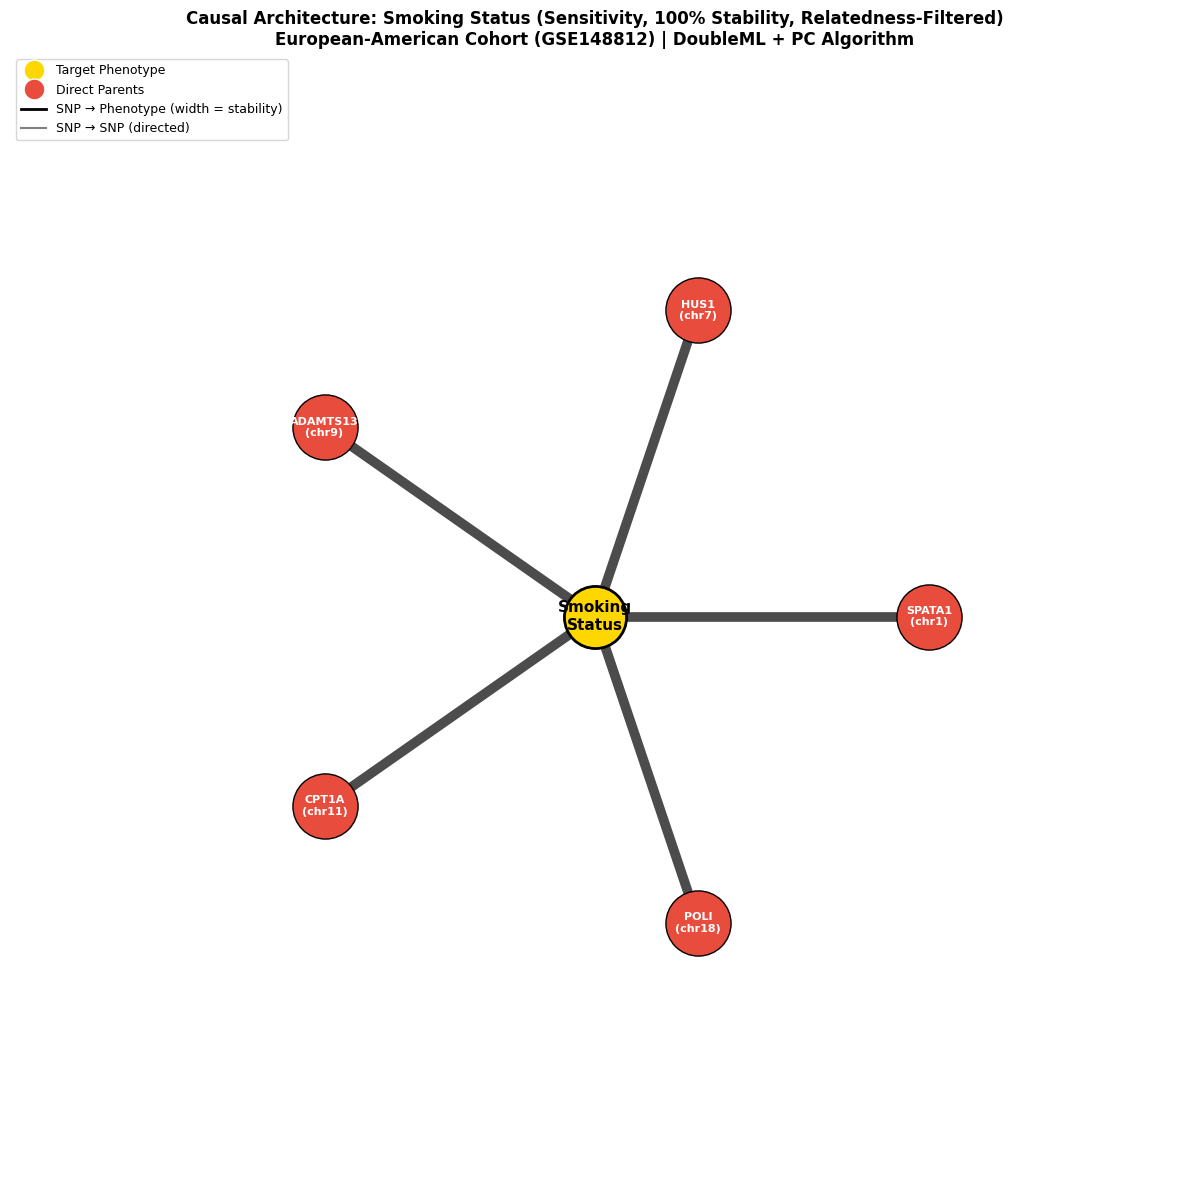

Saved.


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os

out_dir = r"C:\Users\user\Downloads\GSE148812_clean"

def make_label_v2(snp_id, gene_map, pos_lookup, strip_fn):
    gene = gene_map.get(snp_id, "?")
    core = strip_fn(snp_id)
    chrom = pos_lookup.loc[core, "Chr"] if core in pos_lookup.index else "?"
    if gene.startswith("ENSG"):
        gene = "ENSG.." + gene[-6:]
    elif gene.startswith("intergenic_chr"):
        gene = "intergenic"
    return f"{gene}\n(chr{chrom})"

def chr_sort_key(snp_id, pos_lookup, strip_fn):
    core = strip_fn(snp_id)
    if core not in pos_lookup.index:
        return (999, 0)
    chrom = pos_lookup.loc[core, "Chr"]
    try:
        chrom_num = int(chrom)
    except ValueError:
        chrom_num = {"X": 23, "Y": 24, "XY": 25, "MT": 26}.get(chrom, 27)
    return (chrom_num, pos_lookup.loc[core, "MapInfo"])

direct_parents_sorted = sorted(direct_parents, key=lambda s: chr_sort_key(s, position_lookup, strip_address_suffix))

stability_map = dict(zip(shortlist_100_final["probe_id"], shortlist_100_final["stability_fraction"]))

fig, ax = plt.subplots(figsize=(12, 12))
center = np.array([0, 0])
ax.scatter(*center, s=2000, c="gold", zorder=5, edgecolors="black", linewidths=2)
ax.text(*center, "Smoking\nStatus", ha="center", va="center", fontsize=11, fontweight="bold", zorder=6)

inner_r = 4
pos = {"smoking_status": center}
for i, snp in enumerate(direct_parents_sorted):
    angle = 2 * np.pi * i / len(direct_parents_sorted)
    pos[snp] = inner_r * np.array([np.cos(angle), np.sin(angle)])

for u, v in edges_directed:
    if u in pos and v in pos:
        if v == "smoking_status":
            width = 1 + 6 * stability_map.get(u, 0.5)
            color = "black"
        else:
            width = 1.5
            color = "gray"
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color=color, linewidth=width, zorder=1, alpha=0.7)

for u, v in edges_undirected:
    if u in pos and v in pos:
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color="steelblue", linewidth=1.5, linestyle="--", zorder=1, alpha=0.7)

for snp in direct_parents_sorted:
    ax.scatter(*pos[snp], s=2200, c="#e74c3c", zorder=4, edgecolors="black", linewidths=1)
    label = make_label_v2(snp, gene_map, position_lookup, strip_address_suffix)
    ax.text(*pos[snp], label, ha="center", va="center", fontsize=8, fontweight="bold", color="white", zorder=6)

ax.set_xlim(-7, 7)
ax.set_ylim(-7, 7)
ax.axis("off")
ax.set_title("Causal Architecture: Smoking Status (Sensitivity, 100% Stability, Relatedness-Filtered)\nEuropean-American Cohort (GSE148812) | DoubleML + PC Algorithm",
              fontsize=12, fontweight="bold")

legend_elements = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='gold', markersize=15, label='Target Phenotype'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=15, label='Direct Parents'),
    plt.Line2D([0],[0], color='black', linewidth=2, label='SNP → Phenotype (width = stability)'),
    plt.Line2D([0],[0], color='gray', linewidth=1.5, label='SNP → SNP (directed)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "sunflower_smoking_EA_sensitivity_grch37.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [2]:
import numpy as np
import json
import os
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode

def run_pc_get_parents(X, col_names, outcome_name, alpha_val):
    n_nodes = len(col_names)
    outcome_idx = col_names.index(outcome_name)
    bk = BackgroundKnowledge()
    nodes = [GraphNode(name) for name in col_names]
    for i in range(n_nodes - 1):
        bk.add_node_to_tier(nodes[i], 0)
    bk.add_node_to_tier(nodes[outcome_idx], 1)

    cg = pc(data=X, alpha=alpha_val, indep_test=fisherz, stable=True,
            uc_rule=0, uc_priority=2, background_knowledge=bk,
            verbose=False, show_progress=False, node_names=col_names)

    adj = cg.G.graph
    edges_directed, edges_undirected = [], []
    for i in range(n_nodes):
        for j in range(i+1, n_nodes):
            if adj[i,j] == -1 and adj[j,i] == 1:
                edges_directed.append((col_names[i], col_names[j]))
            elif adj[i,j] == 1 and adj[j,i] == -1:
                edges_directed.append((col_names[j], col_names[i]))
            elif adj[i,j] == -1 and adj[j,i] == -1:
                edges_undirected.append((col_names[i], col_names[j]))

    direct_parents = set()
    for u, v in edges_directed:
        if v == outcome_name:
            direct_parents.add(u)
    for u, v in edges_undirected:
        if outcome_name in (u, v):
            direct_parents.add(v if u == outcome_name else u)
    return direct_parents

out_dir = r"C:\Users\user\Downloads\GSE148812_clean"
X_pc_full_smk_ea = np.load(os.path.join(out_dir, "pc_input_smoking_sensitivity.npy"))
with open(os.path.join(out_dir, "pc_col_names_smoking_sensitivity.json")) as f:
    col_names_smk_ea = json.load(f)

for alpha_val in [0.0001, 0.001, 0.005]:
    parents = run_pc_get_parents(X_pc_full_smk_ea, col_names_smk_ea, "smoking_status", alpha_val)
    print(f"alpha={alpha_val}: {len(parents)} direct parents: {sorted(parents)}")

c:\Users\user\Desktop\ai causal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


alpha=0.0001: 0 direct parents: []
alpha=0.001: 5 direct parents: ['exm1387779-0_B_F_1921595005', 'exm619924-0_B_F_1918533121', 'exm71047-0_B_R_1921357564', 'exm793377-0_T_R_1922407882', 'exm935491-0_T_R_1918372056']
alpha=0.005: 7 direct parents: ['exm1387779-0_B_F_1921595005', 'exm2251364-0_T_F_1975257170', 'exm421337-0_B_F_1923050859', 'exm619924-0_B_F_1918533121', 'exm71047-0_B_R_1921357564', 'exm793377-0_T_R_1922407882', 'exm935491-0_T_R_1918372056']


In [3]:
import pandas as pd
import re
import requests
import time

def strip_address_suffix(pid):
    return re.sub(r'_\d+$', '', pid)

def query_ensembl_grch37(chrom, pos, max_retries=3):
    url = f"https://grch37.rest.ensembl.org/overlap/region/human/{chrom}:{int(pos)-1}-{int(pos)+1}?feature=gene;content-type=application/json"
    headers = {"User-Agent": "Mozilla/5.0 (research script)"}
    for attempt in range(max_retries):
        try:
            resp = requests.get(url, headers=headers, timeout=15)
            if resp.status_code == 200:
                return resp.json()
            time.sleep(2 * (attempt + 1))
        except Exception:
            time.sleep(2 * (attempt + 1))
    return None

manifest_path = r"C:\Users\user\Downloads\HumanExome-12-v1-0-B.csv"
manifest_df = pd.read_csv(manifest_path, skiprows=7, low_memory=False)
manifest_df["core_name"] = manifest_df["IlmnID"].map(strip_address_suffix)
pos_lookup = manifest_df.set_index("core_name")[["Chr", "MapInfo"]]

for snp in ["exm2251364-0_T_F_1975257170", "exm421337-0_B_F_1923050859"]:
    core = strip_address_suffix(snp)
    if core in pos_lookup.index:
        chrom = pos_lookup.loc[core, "Chr"]
        pos = pos_lookup.loc[core, "MapInfo"]
        data = query_ensembl_grch37(chrom, pos)
        gene = data[0].get("external_name", "UNKNOWN") if data else f"intergenic_chr{chrom}"
        print(f"{snp[:35]:37s} -> {gene}")
    time.sleep(0.3)

exm2251364-0_T_F_1975257170           -> SACS
exm421337-0_B_F_1923050859            -> USP53
